In [ ]:
# Cell 1 : Install Required Libraries


!pip -q install git+https://github.com/openai/CLIP.git
!pip -q install transformers
!pip -q install datasets
!pip -q install ftfy regex tqdm
!pip -q install matplotlib
!pip -q install pillow
!pip -q install scikit-learn

  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.8/44.8 kB 3.9 MB/s eta 0:00:00


In [ ]:

# Cell 2 : Import Libraries


import os
import random
import numpy as np
import torch

import clip

from PIL import Image
from tqdm import tqdm

import matplotlib.pyplot as plt

from datasets import load_dataset

In [ ]:

# Cell 3 : Reproducibility


SEED = 42

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

device = "cuda" if torch.cuda.is_available() else "cpu"

print("Device :", device)

Device : cuda


In [ ]:

# Cell 4 : Load CLIP


model, preprocess = clip.load("ViT-B/32", device=device)

model.eval()

print("CLIP Loaded Successfully")

100%|████████████████████████████████████████| 338M/338M [00:01<00:00, 288MiB/s]


CLIP Loaded Successfully


In [ ]:
# Install Kaggle

!pip install -q kaggle

In [ ]:
import os

os.makedirs("/root/.kaggle", exist_ok=True)

with open("/root/.kaggle/access_token", "w") as f:
    f.write("KGAT_b5a72f3fcee56464dbd9ed850fcbb622")

os.chmod("/root/.kaggle/access_token", 0o600)

print("Kaggle API configured successfully!")

Kaggle API configured successfully!


In [ ]:
!kaggle datasets list -s flickr-image-dataset

ref                                                            title                                                    size  lastUpdated                 downloadCount  voteCount  usabilityRating  
-------------------------------------------------------------  ------------------------------------------------  -----------  --------------------------  -------------  ---------  ---------------  
hsankesara/flickr-image-dataset                                Flickr Image dataset                               8765396518  2018-06-12 20:34:20.467000          68627        648  0.7058824        
dibyansudiptiman/flickr-8k                                     Flickr8k Image Dataset                               55350806  2020-08-06 15:05:46.750000           2241         13  1                
vencerlanz09/healthy-and-bleached-corals-image-classification  Healthy and Bleached Corals Image Classification     27007922  2023-04-26 07:29:31.007000           3719         95  0.875            
gazu468/fl

In [ ]:
!kaggle datasets download -d hsankesara/flickr-image-dataset

Dataset URL: https://www.kaggle.com/datasets/hsankesara/flickr-image-dataset
License(s): CC0-1.0
100% 8.16G/8.16G [04:04<00:00, 35.9MB/s]



In [ ]:
!unzip -q flickr-image-dataset.zip -d flickr30k

In [ ]:
import os

for root, dirs, files in os.walk("flickr30k"):
    print(root)
    print("Files:", len(files))
    print("-" * 40)

flickr30k
Files: 0
----------------------------------------
flickr30k/flickr30k_images
Files: 1
----------------------------------------
flickr30k/flickr30k_images/flickr30k_images
Files: 31784
----------------------------------------
flickr30k/flickr30k_images/flickr30k_images/flickr30k_images
Files: 31783
----------------------------------------


In [ ]:
import os

for root, dirs, files in os.walk("flickr30k"):
    print("="*80)
    print("Folder :", root)
    print("Directories :", dirs[:10])
    print("Number of files :", len(files))
    print("First 10 files :", files[:10])

Folder : flickr30k
Directories : ['flickr30k_images']
Number of files : 0
First 10 files : []
Folder : flickr30k/flickr30k_images
Directories : ['flickr30k_images']
Number of files : 1
First 10 files : ['results.csv']
Folder : flickr30k/flickr30k_images/flickr30k_images
Directories : ['flickr30k_images']
Number of files : 31784
First 10 files : ['2705922148.jpg', '2612125121.jpg', '3250589803.jpg', '3353950389.jpg', '3173976185.jpg', '2735158990.jpg', '2571096893.jpg', '2857473929.jpg', '4618092593.jpg', '1448065625.jpg']
Folder : flickr30k/flickr30k_images/flickr30k_images/flickr30k_images
Directories : []
Number of files : 31783
First 10 files : ['2705922148.jpg', '2612125121.jpg', '3250589803.jpg', '3353950389.jpg', '3173976185.jpg', '2735158990.jpg', '2571096893.jpg', '2857473929.jpg', '4618092593.jpg', '1448065625.jpg']


In [ ]:
csv_path = "flickr30k/flickr30k_images/results.csv"

with open(csv_path, "r", encoding="utf-8") as f:
    for i in range(15):
        print(repr(f.readline()))

'image_name| comment_number| comment\n'
'1000092795.jpg| 0| Two young guys with shaggy hair look at their hands while hanging out in the yard .\n'
'1000092795.jpg| 1| Two young , White males are outside near many bushes .\n'
'1000092795.jpg| 2| Two men in green shirts are standing in a yard .\n'
'1000092795.jpg| 3| A man in a blue shirt standing in a garden .\n'
'1000092795.jpg| 4| Two friends enjoy time spent together .\n'
'10002456.jpg| 0| Several men in hard hats are operating a giant pulley system .\n'
'10002456.jpg| 1| Workers look down from up above on a piece of equipment .\n'
'10002456.jpg| 2| Two men working on a machine wearing hard hats .\n'
'10002456.jpg| 3| Four men on top of a tall structure .\n'
'10002456.jpg| 4| Three men on a large rig .\n'
'1000268201.jpg| 0| A child in a pink dress is climbing up a set of stairs in an entry way .\n'
'1000268201.jpg| 1| A little girl in a pink dress going into a wooden cabin .\n'
'1000268201.jpg| 2| A little girl climbing the stairs t

In [ ]:

# Cell 7 : Read Flickr30K Captions


import pandas as pd

csv_path = "flickr30k/flickr30k_images/results.csv"

df = pd.read_csv(
    csv_path,
    sep="\\|",
    engine="python"
)

# Remove unwanted spaces in column names
df.columns = [c.strip() for c in df.columns]

# Remove spaces inside every string column
for c in df.columns:
    if df[c].dtype == object:
        df[c] = df[c].str.strip()

print(df.head())
print()

print("Total Rows :", len(df))
print("Unique Images :", df["image_name"].nunique())

       image_name comment_number  \
0  1000092795.jpg              0   
1  1000092795.jpg              1   
2  1000092795.jpg              2   
3  1000092795.jpg              3   
4  1000092795.jpg              4   

                                             comment  
0  Two young guys with shaggy hair look at their ...  
1  Two young , White males are outside near many ...  
2   Two men in green shirts are standing in a yard .  
3       A man in a blue shirt standing in a garden .  
4            Two friends enjoy time spent together .  

Total Rows : 158915
Unique Images : 31783


In [ ]:

# Cell 8 : Select First 200 Images


unique_images = df["image_name"].unique()[:200]

mini_df = (
    df[df["image_name"].isin(unique_images)]
      .groupby("image_name")
      .first()
      .reset_index()
)

print(mini_df.head())

print()

print("Images :", len(mini_df))

       image_name comment_number  \
0  1000092795.jpg              0   
1    10002456.jpg              0   
2  1000268201.jpg              0   
3  1000344755.jpg              0   
4  1000366164.jpg              0   

                                             comment  
0  Two young guys with shaggy hair look at their ...  
1  Several men in hard hats are operating a giant...  
2  A child in a pink dress is climbing up a set o...  
3  Someone in a blue shirt and hat is standing on...  
4  Two men , one in a gray shirt , one in a black...  

Images : 200


In [ ]:
import os

base = "flickr30k/flickr30k_images/flickr30k_images"

print(os.listdir(base)[:10])

['2705922148.jpg', '2612125121.jpg', '3250589803.jpg', '3353950389.jpg', '3173976185.jpg', '2735158990.jpg', '2571096893.jpg', '2857473929.jpg', '4618092593.jpg', '1448065625.jpg']


In [ ]:

# Cell 10 : Keep First 200 Images


selected_images = df["image_name"].unique()[:200]

mini_df = df[df["image_name"].isin(selected_images)].copy()

mini_df.reset_index(drop=True, inplace=True)

print(mini_df.head())

print()

print("Images :", mini_df["image_name"].nunique())
print("Captions :", len(mini_df))

       image_name comment_number  \
0  1000092795.jpg              0   
1  1000092795.jpg              1   
2  1000092795.jpg              2   
3  1000092795.jpg              3   
4  1000092795.jpg              4   

                                             comment  
0  Two young guys with shaggy hair look at their ...  
1  Two young , White males are outside near many ...  
2   Two men in green shirts are standing in a yard .  
3       A man in a blue shirt standing in a garden .  
4            Two friends enjoy time spent together .  

Images : 200
Captions : 1000


In [ ]:

# Cell 11 : Image Folder


IMAGE_DIR = "flickr30k/flickr30k_images/flickr30k_images"

Two young guys with shaggy hair look at their hands while hanging out in the yard .


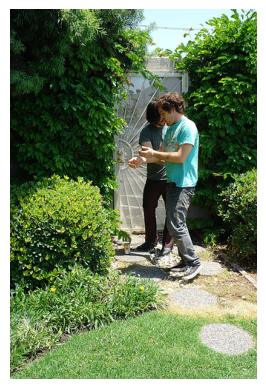

In [ ]:
from PIL import Image
import matplotlib.pyplot as plt
import os

sample = mini_df.iloc[0]

img = Image.open(os.path.join(
    IMAGE_DIR,
    sample.image_name
))

plt.imshow(img)
plt.axis("off")

print(sample.comment)

In [ ]:
import torch
from torch.utils.data import Dataset

class FlickrSubset(Dataset):

    def __init__(self, dataframe, image_dir, preprocess):

        self.df = dataframe
        self.image_dir = image_dir
        self.preprocess = preprocess

    def __len__(self):

        return len(self.df)

    def __getitem__(self, idx):

        row = self.df.iloc[idx]

        image = Image.open(
            os.path.join(
                self.image_dir,
                row.image_name
            )
        ).convert("RGB")

        image = self.preprocess(image)

        caption = row.comment

        return image, caption

In [ ]:
from torch.utils.data import DataLoader

dataset = FlickrSubset(
    mini_df,
    IMAGE_DIR,
    preprocess
)

loader = DataLoader(
    dataset,
    batch_size=32,
    shuffle=False
)

In [ ]:

# Cell 15 : Extract Image Features


import torch
import os
from PIL import Image
from tqdm import tqdm

image_names = mini_df["image_name"].unique()

image_features = []

with torch.no_grad():

    for image_name in tqdm(image_names):

        image = Image.open(
            os.path.join(
                IMAGE_DIR,
                image_name
            )
        ).convert("RGB")

        image = preprocess(image).unsqueeze(0).to(device)

        feature = model.encode_image(image)

        feature = feature / feature.norm(dim=-1, keepdim=True)

        image_features.append(feature.cpu())

image_features = torch.cat(image_features)

print(image_features.shape)

100%|██████████| 200/200 [00:04<00:00, 49.16it/s]

torch.Size([200, 512])


In [ ]:

# Cell 16 : Extract Text Features


captions = mini_df["comment"].tolist()

text_features = []

with torch.no_grad():

    for caption in tqdm(captions):

        tokens = clip.tokenize(caption).to(device)

        feature = model.encode_text(tokens)

        feature = feature / feature.norm(dim=-1, keepdim=True)

        text_features.append(feature.cpu())

text_features = torch.cat(text_features)

print(text_features.shape)

100%|██████████| 1000/1000 [00:08<00:00, 111.94it/s]

torch.Size([1000, 512])


In [ ]:

# Cell 17 : Similarity Matrix


similarity = image_features @ text_features.T

print(similarity.shape)

torch.Size([200, 1000])


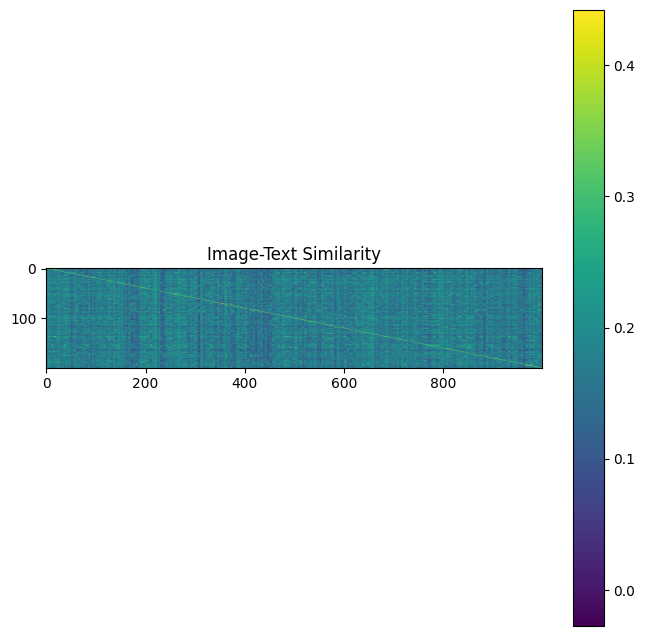

In [ ]:

# Cell 18 : Plot Similarity Matrix


import matplotlib.pyplot as plt

plt.figure(figsize=(8,8))

plt.imshow(similarity)

plt.colorbar()

plt.title("Image-Text Similarity")

plt.show()

In [ ]:

# Cell 19 : Recall@K


def recall_at_k(similarity, k):

    sim = similarity.numpy()

    correct = 0

    for i in range(sim.shape[0]):

        ranking = sim[i].argsort()[::-1][:k]

        gt = set(range(i*5, i*5 + 5))

        if len(gt.intersection(ranking)) > 0:
            correct += 1

    return correct / sim.shape[0]

In [ ]:
print("Recall@1 :", recall_at_k(similarity,1))
print("Recall@5 :", recall_at_k(similarity,5))
print("Recall@10 :", recall_at_k(similarity,10))

Recall@1 : 0.93
Recall@5 : 0.985
Recall@10 : 0.99


In [ ]:

# Cell 20 : Hyperparameters


EPSILON = 8 / 255

STEP_SIZE = 1 / 255

EPOCHS = 10

print(EPSILON)

0.03137254901960784


In [ ]:

# Cell 21 : Universal Perturbation


delta = torch.zeros(
    (3,224,224),
    device=device,
    requires_grad=True
)

print(delta.shape)

torch.Size([3, 224, 224])


In [ ]:

# Cell 22 : Optimizer


optimizer = torch.optim.Adam(
    [delta],
    lr=STEP_SIZE
)

In [ ]:

# Cell 23 : Prepare Text Features


text_features_gpu = text_features.to(device)

print(text_features_gpu.shape)

torch.Size([1000, 512])


In [ ]:

# Cell 24 : Improved UAP Training


import torch.nn.functional as F

loss_history = []

image_names = mini_df["image_name"].unique()

for epoch in range(EPOCHS):

    optimizer.zero_grad()

    epoch_loss = 0

    for i, image_name in enumerate(image_names):

        image = Image.open(
            os.path.join(IMAGE_DIR, image_name)
        ).convert("RGB")

        image = preprocess(image).unsqueeze(0).to(device)

        adv = image + delta.unsqueeze(0)

        adv = torch.clamp(adv,0,1)

        adv_feature = model.encode_image(adv)
        adv_feature = F.normalize(adv_feature,dim=-1)

        similarities = adv_feature @ text_features_gpu.T

        gt = torch.arange(i*5,(i+1)*5,device=device)

        correct_score = similarities[:,gt].mean()

        loss = correct_score

        epoch_loss += loss

    epoch_loss = epoch_loss / len(image_names)

    (-epoch_loss).backward()

    optimizer.step()

    with torch.no_grad():

        delta.clamp_(-EPSILON,EPSILON)

    loss_history.append(epoch_loss.item())

    print(
        f"Epoch {epoch+1}/{EPOCHS}  "
        f"Similarity={epoch_loss.item():.4f}"
    )

Epoch 1/10  Similarity=0.2983
Epoch 2/10  Similarity=0.2988
Epoch 3/10  Similarity=0.2993
Epoch 4/10  Similarity=0.2998
Epoch 5/10  Similarity=0.3000
Epoch 6/10  Similarity=0.3005
Epoch 7/10  Similarity=0.3010
Epoch 8/10  Similarity=0.3010
Epoch 9/10  Similarity=0.3018
Epoch 10/10  Similarity=0.3022


In [ ]:

# Cell 25 : Adversarial Image Features


adv_features = []

with torch.no_grad():

    for image_name in image_names:

        image = Image.open(
            os.path.join(
                IMAGE_DIR,
                image_name
            )
        ).convert("RGB")

        image = preprocess(image).unsqueeze(0).to(device)

        adv = image + delta.unsqueeze(0)

        adv = torch.clamp(adv,0,1)

        feature = model.encode_image(adv)

        feature = feature / feature.norm(dim=-1,keepdim=True)

        adv_features.append(feature.cpu())

adv_features = torch.cat(adv_features)

print(adv_features.shape)

torch.Size([200, 512])


In [ ]:

# Cell 26


adv_similarity = adv_features @ text_features.T

print(adv_similarity.shape)

torch.Size([200, 1000])


In [ ]:
print("Recall@1 :", recall_at_k(adv_similarity,1))
print("Recall@5 :", recall_at_k(adv_similarity,5))
print("Recall@10 :", recall_at_k(adv_similarity,10))

Recall@1 : 0.835
Recall@5 : 0.94
Recall@10 : 0.965


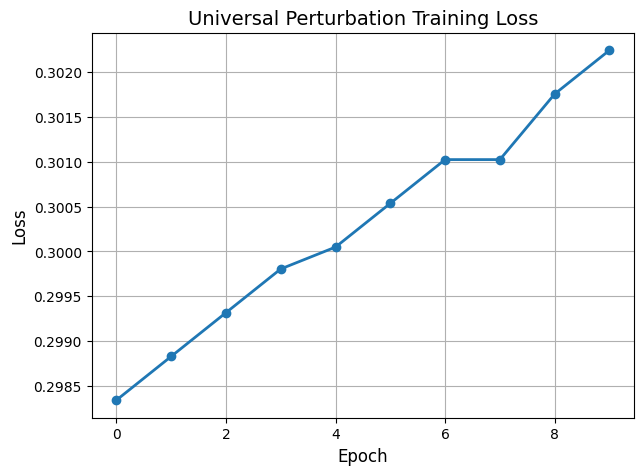

In [ ]:

# Plot Loss Curve


plt.figure(figsize=(7,5))

plt.plot(loss_history, marker='o', linewidth=2)

plt.xlabel("Epoch", fontsize=12)
plt.ylabel("Loss", fontsize=12)
plt.title("Universal Perturbation Training Loss", fontsize=14)

plt.grid(True)

plt.savefig("loss_curve.png", dpi=300, bbox_inches="tight")

plt.show()

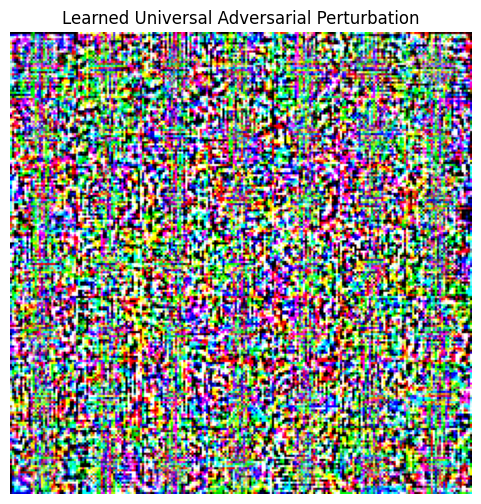

In [ ]:

# Visualize UAP


uap = delta.detach().cpu().permute(1,2,0).numpy()

# Normalize for visualization
uap_vis = (uap - uap.min()) / (uap.max() - uap.min())

plt.figure(figsize=(6,6))

plt.imshow(uap_vis)

plt.title("Learned Universal Adversarial Perturbation")

plt.axis("off")

plt.savefig("uap.png", dpi=300, bbox_inches="tight")

plt.show()

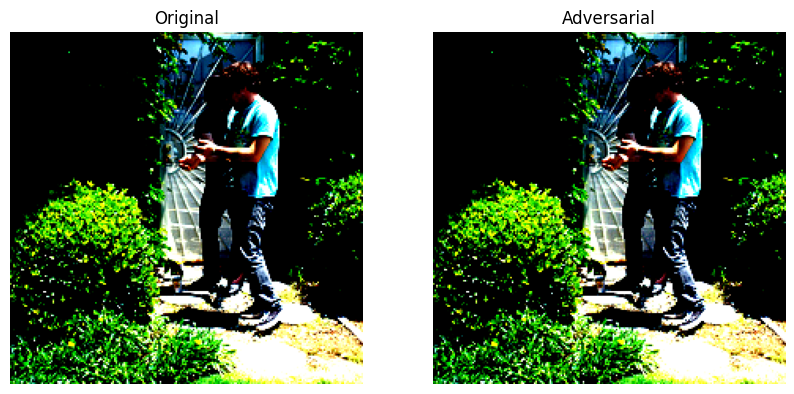

In [ ]:

# Original vs Adversarial Image


sample_image = Image.open(
    os.path.join(
        IMAGE_DIR,
        image_names[0]
    )
).convert("RGB")

img = preprocess(sample_image)

adv = torch.clamp(
    img + delta.detach().cpu(),
    0,
    1
)

orig = img.permute(1,2,0).numpy()
adv = adv.permute(1,2,0).numpy()

plt.figure(figsize=(10,5))

plt.subplot(1,2,1)
plt.imshow(orig)
plt.title("Original")
plt.axis("off")

plt.subplot(1,2,2)
plt.imshow(adv)
plt.title("Adversarial")
plt.axis("off")

plt.savefig("comparison.png", dpi=300)

plt.show()

In [ ]:
import pandas as pd

results = pd.DataFrame({
    "Method":["Baseline","After UAP"],
    "Recall@1":[0.93,0.835],
    "Recall@5":[0.985,0.94],
    "Recall@10":[0.99,0.965]
})

results.to_csv("results.csv",index=False)

results

,Method,Recall@1,Recall@5,Recall@10
0,Baseline,0.930,0.985,0.990
1,After UAP,0.835,0.940,0.965


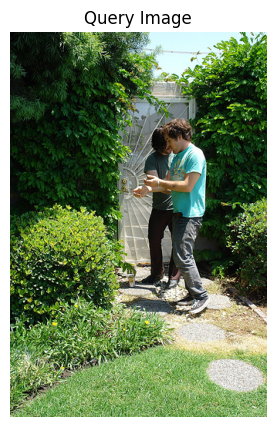

TOP-5 RETRIEVAL BEFORE ATTACK

Rank 1 (✓ Correct)
Score : 0.3240
Two young guys with shaggy hair look at their hands while hanging out in the yard .

Rank 2 (✓ Correct)
Score : 0.3108
A man in a blue shirt standing in a garden .

Rank 3 (✓ Correct)
Score : 0.3101
Two men in green shirts are standing in a yard .

Rank 4 (✓ Correct)
Score : 0.3025
Two young , White males are outside near many bushes .

Rank 5 (✓ Correct)
Score : 0.2913
Two friends enjoy time spent together .


TOP-5 RETRIEVAL AFTER ATTACK

Rank 1 (✗ Wrong)
Score : 0.2812
A Asian man wearing a white top and baby blue bottoms is using a broom to remove the dirt of the pavement .

Rank 2 (✗ Wrong)
Score : 0.2783
Two skateboarders .

Rank 3 (✗ Wrong)
Score : 0.2732
A boy takes a jump on his skateboard while another boy with a skateboard watches .

Rank 4 (✗ Wrong)
Score : 0.2710
Asian man sweeping the walkway .

Rank 5 (✗ Wrong)
Score : 0.2695
A man in green pants walking down the road .


In [ ]:

# Retrieval Example: Before vs After UAP


import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
import os

sample_idx = 0

# Display the query image
img_path = os.path.join(IMAGE_DIR, image_names[sample_idx])
img = Image.open(img_path).convert("RGB")

plt.figure(figsize=(5,5))
plt.imshow(img)
plt.title("Query Image")
plt.axis("off")
plt.show()

# Ground-truth caption indices
gt = set(range(sample_idx * 5, sample_idx * 5 + 5))

# ---------- BEFORE ----------
before_scores = similarity[sample_idx].detach().cpu().numpy()
before_rank = np.argsort(-before_scores)

print("=" * 80)
print("TOP-5 RETRIEVAL BEFORE ATTACK")
print("=" * 80)

for rank in range(5):
    idx = before_rank[rank]
    correct = "✓ Correct" if idx in gt else "✗ Wrong"

    print(f"\nRank {rank+1} ({correct})")
    print(f"Score : {before_scores[idx]:.4f}")
    print(mini_df.iloc[idx]["comment"])

# ---------- AFTER ----------
after_scores = adv_similarity[sample_idx].detach().cpu().numpy()
after_rank = np.argsort(-after_scores)

print("\n")
print("=" * 80)
print("TOP-5 RETRIEVAL AFTER ATTACK")
print("=" * 80)

for rank in range(5):
    idx = after_rank[rank]
    correct = "✓ Correct" if idx in gt else "✗ Wrong"

    print(f"\nRank {rank+1} ({correct})")
    print(f"Score : {after_scores[idx]:.4f}")
    print(mini_df.iloc[idx]["comment"])

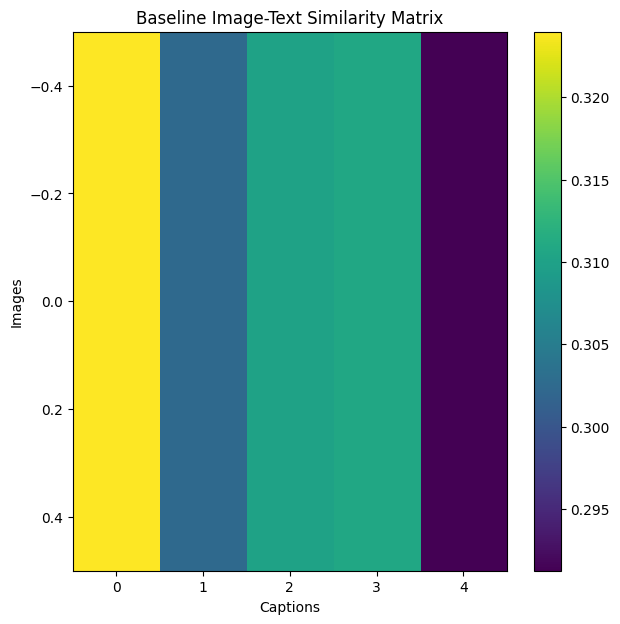

In [ ]:
plt.figure(figsize=(7,7))

plt.imshow(similarity.detach().cpu().numpy(), aspect='auto', cmap="viridis")

plt.title("Baseline Image-Text Similarity Matrix")
plt.xlabel("Captions")
plt.ylabel("Images")

plt.colorbar()

plt.savefig("baseline_similarity.png", dpi=300, bbox_inches="tight")

plt.show()

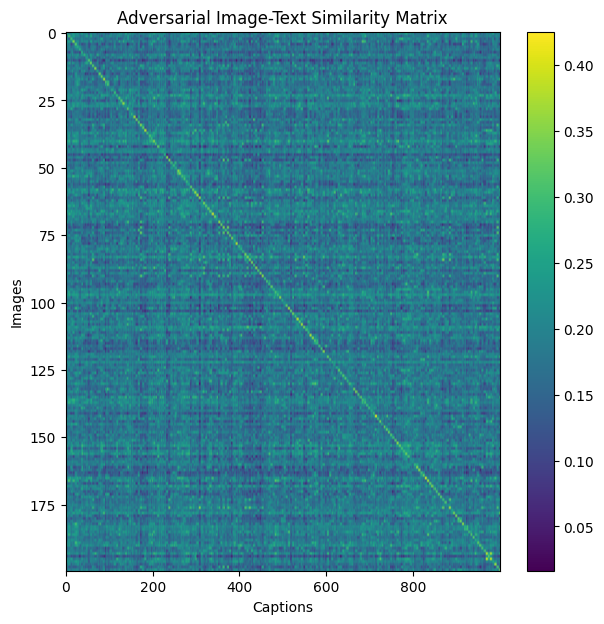

In [ ]:
plt.figure(figsize=(7,7))

plt.imshow(adv_similarity.detach().cpu().numpy(), aspect='auto', cmap="viridis")

plt.title("Adversarial Image-Text Similarity Matrix")
plt.xlabel("Captions")
plt.ylabel("Images")

plt.colorbar()

plt.savefig("adv_similarity.png", dpi=300, bbox_inches="tight")

plt.show()